In [2]:
import pandas as pd
import numpy as np
from datascience import *
import matplotlib.pyplot as plots
%matplotlib inline

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Import and Clean datasets

In [3]:
major_countries = {
    'USA': 'United States',
    'CAN': 'Canada',
    'MEX': 'Mexico',
    'BRA': 'Brazil',
    'ARG': 'Argentina',
    'CHL': 'Chile',
    'COL': 'Colombia',
    'PER': 'Peru',
    'URY': 'Uruguay',
    'PRY': 'Paraguay',
    'BOL': 'Bolivia',
    'ECU': 'Ecuador',

    'GBR': 'United Kingdom',
    'FRA': 'France',
    'DEU': 'Germany',
    'ITA': 'Italy',
    'ESP': 'Spain',
    'PRT': 'Portugal',
    'NLD': 'Netherlands',
    'BEL': 'Belgium',
    'CHE': 'Switzerland',
    'AUT': 'Austria',
    'SWE': 'Sweden',
    'NOR': 'Norway',
    'DNK': 'Denmark',
    'FIN': 'Finland',
    'IRL': 'Ireland',
    'POL': 'Poland',
    'CZE': 'Czech Republic',
    'GRC': 'Greece',
    'HUN': 'Hungary',
    'ROU': 'Romania',
    'UKR': 'Ukraine',
    'RUS': 'Russia',

    'CHN': 'China',
    'IND': 'India',
    'JPN': 'Japan',
    'KOR': 'South Korea',
    'IDN': 'Indonesia',
    'THA': 'Thailand',
    'VNM': 'Vietnam',
    'PHL': 'Philippines',
    'MYS': 'Malaysia',
    'SGP': 'Singapore',
    'PAK': 'Pakistan',
    'BGD': 'Bangladesh',
    'LKA': 'Sri Lanka',
    'NPL': 'Nepal',
    'AFG': 'Afghanistan',

    'AUS': 'Australia',
    'NZL': 'New Zealand',

    'ZAF': 'South Africa',
    'NGA': 'Nigeria',
    'EGY': 'Egypt',
    'ETH': 'Ethiopia',
    'KEN': 'Kenya',
    'DZA': 'Algeria',
    'MAR': 'Morocco',
    'GHA': 'Ghana',
    'TZA': 'Tanzania',
    'UGA': 'Uganda',
    'CMR': 'Cameroon',
    'SDN': 'Sudan',

    'TUR': 'Turkey',
    'SAU': 'Saudi Arabia',
    'IRN': 'Iran',
    'IRQ': 'Iraq',
    'ISR': 'Israel',
    'ARE': 'United Arab Emirates',
    'QAT': 'Qatar',
    'KWT': 'Kuwait',

    'DOM': 'Dominican Republic',
    'HTI': 'Haiti',
    'JAM': 'Jamaica'
}

In [4]:
#upload all tables
countries = Table.read_table("datasets/countries.csv")
population = Table.read_table("datasets/population.csv")
fertility = Table.read_table("datasets/fertility.csv")
mortality = Table.read_table("datasets/child_mortality.csv")
gdp = Table.read_table("datasets/gdp_per_capita.csv")
life_expectancy = Table.read_table("datasets/life_expectancy.csv")

countries

name,income_groups,code,world_4region
Abkhazia,nan,nan,europe
Afghanistan,low_income,AFG,asia
Akrotiri and Dhekelia,nan,nan,europe
Albania,upper_middle_income,ALB,europe
Algeria,upper_middle_income,DZA,africa
American Samoa,upper_middle_income,ASM,asia
Andorra,high_income,AND,europe
Angola,upper_middle_income,AGO,africa
Anguilla,nan,AIA,americas
Antarctica,nan,nan,europe


In [5]:
#select years 2000 - 2023 from all tables and only select major countries
major_codes = list(major_countries.keys())

countries = countries.where('code',are.contained_in(list(major_countries.keys())))

population = population.select('code','year','population_total').where('year', are.between(2000, 2016)).where('code', are.contained_in(list(major_countries.keys()))
)
fertility = fertility.select('code','year','fertility').where('year', are.between(2000, 2016)).where('code', are.contained_in(list(major_countries.keys()))
)
mortality = mortality.select('code','year','child_mortality').where('year', are.between(2000, 2016)).where('code', are.contained_in(list(major_countries.keys()))
)
gdp = gdp.select('code','year','gdp_per_capita').where('year', are.between(2000, 2016)).where('code', are.contained_in(list(major_countries.keys()))
)
life_expectancy = life_expectancy.select('code','year','life_expectancy').where('year', are.between(2000,2016)).where('code', are.contained_in(list(major_countries.keys())))

In [6]:
#Check to see all tables have equal amount of rows

#population.where('year', 2015).num_rows
#fertility.where('year', 2015).num_rows
#mortality.where('year', 2015).num_rows
#gdp.where('year', 2015).num_rows
#life_expectancy.where('year', 2015).num_rows



In [28]:
merged_dataset = countries.join('code', population)
merged_dataset = merged_dataset.join(['code', 'year'], fertility)
merged_dataset = merged_dataset.join(['code', 'year'], mortality)
merged_dataset = merged_dataset.join(['code','year'], gdp)
merged_dataset = merged_dataset.join(['code','year'], life_expectancy)

merged_dataset

code,year,name,income_groups,world_4region,population_total,fertility,child_mortality,gdp_per_capita,life_expectancy
AFG,2000,Afghanistan,low_income,asia,19701940,7.73,137,1617.83,50.1
AFG,2001,Afghanistan,low_income,asia,20531160,7.62,133.8,1454.11,50.4
AFG,2002,Afghanistan,low_income,asia,21487079,7.48,130.3,1774.31,51
AFG,2003,Afghanistan,low_income,asia,22507368,7.32,126.8,1815.93,51.4
AFG,2004,Afghanistan,low_income,asia,23499850,7.14,123.2,1776.92,51.8
AFG,2005,Afghanistan,low_income,asia,24399948,6.93,119.6,1908.11,52
AFG,2006,Afghanistan,low_income,asia,25183615,6.7,116.3,1929.72,52.1
AFG,2007,Afghanistan,low_income,asia,25877544,6.46,113.2,2155.35,52.4
AFG,2008,Afghanistan,low_income,asia,26528741,6.2,110.4,2191.5,52.8
AFG,2009,Afghanistan,low_income,asia,27207291,5.93,107.6,2565.02,53.3


# 2. Create Machine Learning Model

In [8]:
#convert to dataframe
df = merged_dataset.to_df()
df.drop(columns=['income_groups','world_4region'])

,code,year,name,population_total,fertility,child_mortality,gdp_per_capita,life_expectancy
0,AFG,2015,Afghanistan,32526562,4.47,91.1,2967.6921,53.8
1,ARE,2015,United Arab Emirates,9156963,1.77,6.8,75238.5550,75.4
2,ARG,2015,Argentina,43416755,2.15,12.5,28669.2070,76.5
3,AUS,2015,Australia,23968973,1.88,3.5,55879.9960,82.3
4,AUT,2015,Austria,8544586,1.50,3.5,60951.6880,81.3
...,...,...,...,...,...,...,...,...
69,UKR,2015,Ukraine,44823765,1.49,9.0,15403.7100,71.5
70,URY,2015,Uruguay,3431555,2.03,10.1,28941.6290,76.8
71,USA,2015,United States,321773631,1.97,6.5,64359.4730,79.1
72,VNM,2015,Vietnam,93447601,1.70,21.7,9248.0240,75.4


(74, 1) (74, 1)


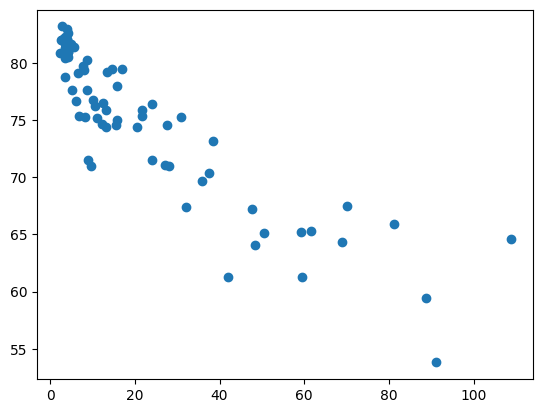

In [9]:
#split data into x(inputs) and y(output)
X = df.drop(columns=['code','year','name','income_groups','world_4region','life_expectancy'])
y = df[['life_expectancy']]

print(X[['child_mortality']].shape, y.shape)
plots.scatter(X['child_mortality'], y)
plots.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

In [11]:
model.score(X_test, y_test)

0.7858245190562542

In [12]:
mse = mean_squared_error(y_test, y_predict)**0.5
mse

3.631957525340382

In [13]:
#function to test model using any amount of inputs
def test_model(input_columns):
    X = df[input_columns]
    y = df['life_expectancy']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=42, test_size=0.2
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_predict = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    rmse = mean_squared_error(y_test, y_predict) ** 0.5
    
    print("Inputs:", input_columns)
    print("R²:", r2)
    print("RMSE:", rmse)
    
    return r2, rmse

# 3. Test Model

In [14]:
test_model(['child_mortality'])

Inputs: ['child_mortality']
R²: 0.7965761766735966
RMSE: 3.539621234534461


(0.7965761766735966, 3.539621234534461)

In [15]:
test_model(['fertility'])

Inputs: ['fertility']
R²: 0.49092617128040394
RMSE: 5.599461602543357


(0.49092617128040394, 5.599461602543357)

In [16]:
test_model(['gdp_per_capita'])

Inputs: ['gdp_per_capita']
R²: 0.43936868132412965
RMSE: 5.876172861819533


(0.43936868132412965, 5.876172861819533)

In [17]:
test_model(['population_total'])

Inputs: ['population_total']
R²: -0.11618367133937957
RMSE: 8.291320784929761


(-0.11618367133937957, 8.291320784929761)

In [18]:
test_model(['child_mortality','gdp_per_capita'])

Inputs: ['child_mortality', 'gdp_per_capita']
R²: 0.8240948115142473
RMSE: 3.2915102383069375


(0.8240948115142473, 3.2915102383069375)

In [19]:
test_model(['child_mortality','fertility'])

Inputs: ['child_mortality', 'fertility']
R²: 0.7757185398968275
RMSE: 3.716657768490242


(0.7757185398968275, 3.716657768490242)

In [20]:
test_model(['fertility','gdp_per_capita'])

Inputs: ['fertility', 'gdp_per_capita']
R²: 0.6181971058629259
RMSE: 4.849260262657593


(0.6181971058629259, 4.849260262657593)

In [21]:
test_model(['population_total','fertility','gdp_per_capita'])

Inputs: ['population_total', 'fertility', 'gdp_per_capita']
R²: 0.5701241425717233
RMSE: 5.145497992126311


(0.5701241425717233, 5.145497992126311)

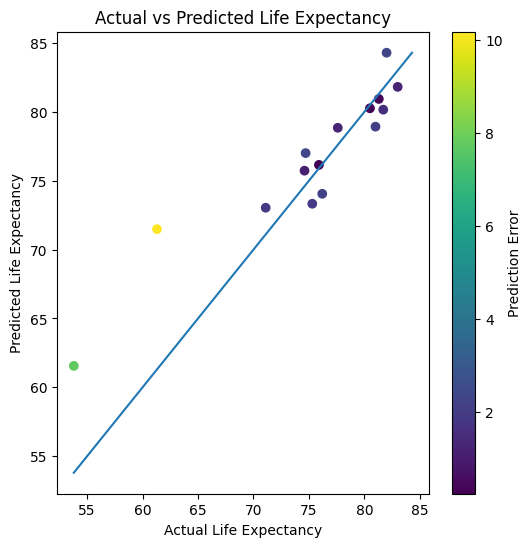

In [22]:
def actual_vs_predicted_plot(y_test, y_predict):
    plots.figure(figsize=(6,6))
    
    errors = abs(y_test.values - y_predict)
    
    plots.scatter(
        y_test.values,
        y_predict,
        c=errors,
        cmap='viridis'
    )
    
    minimum = min(y_test.values.min(), y_predict.min())
    maximum = max(y_test.values.max(), y_predict.max())
    
    plots.plot(
        [minimum, maximum],
        [minimum, maximum]
    )
    
    plots.xlabel('Actual Life Expectancy')
    plots.ylabel('Predicted Life Expectancy')
    plots.title('Actual vs Predicted Life Expectancy')
    
    plots.colorbar(label='Prediction Error')
    
    plots.show()
    
actual_vs_predicted_plot(y_test, y_predict)